In [1]:
%%capture
!pip install -U transformers bitsandbytes accelerate
!pip install -U bitsandbytes>=0.46.1

In [2]:
import torch
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

In [3]:
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


**Load FP32 Model**

In [4]:
model_id = "AdamLucek/Orpo-Llama-3.2-1B-15k"

# FP32 Model
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    device_map="auto"
)

print("FP32 Model Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/909 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

FP32 Model Loaded


**Load INT8 Quantized Model**


In [5]:
#INT8 config
bnb_config_8bit = BitsAndBytesConfig(
    load_in_8bit=True
)

model_8bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_8bit,
    low_cpu_mem_usage=True,
    device_map="auto"
)

print("INT8 Model Loaded")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

INT8 Model Loaded


**Load INT4 Quantized Model**


In [6]:
bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_4bit,
    low_cpu_mem_usage=True,
    device_map="auto"
)

print("INT4 Model Loaded")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

INT4 Model Loaded


**Load Tokenizer**

In [7]:
# Loading Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/419 [00:00<?, ?B/s]

In [8]:
# Print model size
print(f"Base model size: {base_model.get_memory_footprint():,} bytes\n")
print(f"8bit model size: {model_8bit.get_memory_footprint():,} bytes\n")
print(f"4bit model size: {model_4bit.get_memory_footprint():,} bytes\n")


Base model size: 4,943,274,240 bytes

8bit model size: 1,498,558,720 bytes

4bit model size: 1,012,019,456 bytes



**GPU Memory Footprint**

In [9]:
results = []

results.append({
    "Model": "FP32",
    "Memory_MB": base_model.get_memory_footprint() / 1024**2
})

results.append({
    "Model": "INT8",
    "Memory_MB": model_8bit.get_memory_footprint() / 1024**2
})

results.append({
    "Model": "INT4",
    "Memory_MB": model_4bit.get_memory_footprint() / 1024**2
})

print(pd.DataFrame(results))

  Model    Memory_MB
0  FP32  4714.273682
1  INT8  1429.136963
2  INT4   965.136963


**Compare the First layer**

A deeper look into the literal weights of the first layer in each version

In [10]:
# Looking at the full model architecture
base_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128258, 2048, padding_idx=128257)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,)

In [11]:
# Weights from the first layer
base_weights = base_model.model.layers[0].self_attn.q_proj.weight.data
print("orginal Weights:")
print(base_weights)
print("Shape: ", base_weights.shape, "\n")
print("-" * 50, "\n")

# Weights from the first layer - 8bit
weights_8bit = model_8bit.model.layers[0].self_attn.q_proj.weight.data
print("INT8 weights:")
print(weights_8bit)
print("Shape: ", weights_8bit.shape, "\n")
print("-" * 50, "\n")

# Weights from the first layer - 4bit
weights_4bit = model_4bit.model.layers[0].self_attn.q_proj.weight.data
print("INT4 weights:")
print(weights_4bit)
print("Shape: ", weights_4bit.shape, "\n")

orginal Weights:
tensor([[-0.0183,  0.0071,  0.0218,  ..., -0.0070, -0.0089,  0.0149],
        [ 0.0112,  0.0593,  0.0630,  ..., -0.0334, -0.0147,  0.0058],
        [ 0.0182,  0.0141,  0.0362,  ..., -0.0432, -0.0388, -0.0233],
        ...,
        [ 0.0305,  0.0289,  0.0801,  ..., -0.0768, -0.0311, -0.0333],
        [ 0.0242, -0.0325,  0.0369,  ..., -0.0124, -0.0268, -0.0150],
        [-0.0264, -0.0498, -0.0210,  ...,  0.0602,  0.0130, -0.0008]],
       device='cuda:0')
Shape:  torch.Size([2048, 2048]) 

-------------------------------------------------- 

INT8 weights:
tensor([[-49,  19,  59,  ..., -19, -24,  40],
        [ 13,  69,  73,  ..., -39, -17,   7],
        [ 17,  13,  34,  ..., -40, -36, -22],
        ...,
        [ 16,  15,  43,  ..., -41, -17, -18],
        [ 36, -48,  54,  ..., -18, -39, -22],
        [-14, -27, -11,  ...,  32,   7,   0]], device='cuda:0',
       dtype=torch.int8)
Shape:  torch.Size([2048, 2048]) 

-------------------------------------------------- 

INT

**Testing Generation**

Running the same prompt through each model version

In [12]:
# Function for Generating with the models
def generate_response(model, message):

  # Format msg
  msg = [{"role": "user", "content": message}]
  prompt = tokenizer.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)

  # Tokenize and generate
  inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

  torch.cuda.synchronize()
  start = time.time()

  outputs = model.generate(
      **inputs,
      max_new_tokens=256,
      temperature=0.7,
      do_sample=True,
      top_k=50,
      top_p=0.95
  )

  torch.cuda.synchronize()
  inference_time = time.time() - start

  # Decode
  response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )
  return response, inference_time

**Generate Response**

In [13]:
prompt = "Explain quantization in large language models."

# FP32
base_response, fp32_time = generate_response(base_model, prompt)

# INT8
int8_response, int8_time = generate_response(model_8bit, prompt)

# INT4
int4_response, int4_time = generate_response(model_4bit, prompt)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


In [14]:
print("FP32 Response:\n")
print(base_response)
print("-" * 50)

print("\nINT8 Response:\n")
print(int8_response)
print("-" * 50)

print("\nINT4 Response:\n")
print(int4_response)

FP32 Response:

user
Explain quantization in large language models.
assistant
Quantization is a technique used in machine learning and artificial intelligence to reduce the size of the model parameters, which can lead to faster training and reduced memory usage. It involves converting the continuous representation of the data (e.g. numbers or text) into a discrete representation that can be represented by a smaller number of bits (e.g. 8 bits or 16 bits).

The main idea behind quantization is to map the continuous data to a discrete representation that is easily computable and has a fixed number of bits. This allows for faster training and computation, especially in cases where the data is large and the number of parameters is large.

There are several ways to quantize the data, and the choice of method depends on several factors, including the type of data, the nature of the model, and the desired accuracy.

One popular method is called quantized floating-point representation (QFPR), 

**Calculating Perplexity**

Perplexity is a measure of how well the model predicts the next token where:

  * Lower Perplexity = model is more confident / accurate in its prediction
  * More Perplexity = model is more uncertain / confused

In [15]:
def calculate_perplexity(model,tokenizer, text):

    # Encode the txt
    encodings = tokenizer(text,return_tensors="pt").to("cuda")

    # Define input_ids and target_ids
    input_ids = encodings.input_ids
    target_ids = input_ids.clone()

    with torch.no_grad():
      # Forward pass through the model
      outputs = model(input_ids,labels=input_ids)

      # Loss calculation
      loss = outputs.loss

      # Perplexity calculation
      perplexity = torch.exp(loss)

    return perplexity.item()

In [16]:
fp32_ppl = calculate_perplexity(base_model, tokenizer, base_response[0])
int8_ppl = calculate_perplexity(model_8bit, tokenizer, int8_response[0])
int4_ppl = calculate_perplexity(model_4bit, tokenizer, int4_response[0])

In [17]:
import pandas as pd
results_df = pd.DataFrame({
    "Model": ["FP32", "INT8", "INT4"],
    "Inference_Time": [
        fp32_time,
        int8_time,
        int4_time
    ],
    "Perplexity": [
        fp32_ppl,
        int8_ppl,
        int4_ppl
    ],
    "Memory_MB": [
        base_model.get_memory_footprint()/1024**2,
        model_8bit.get_memory_footprint()/1024**2,
        model_4bit.get_memory_footprint()/1024**2
    ]
})

print(results_df)

  Model  Inference_Time    Perplexity    Memory_MB
0  FP32       13.469060  41381.984375  4714.273682
1  INT8       27.715272  42282.968750  1429.136963
2  INT4        9.639929  40599.855469   965.136963


**Plot: Inference Time**

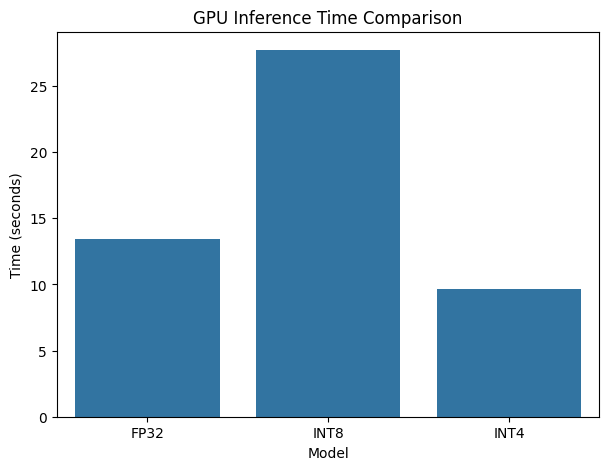

In [18]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="Inference_Time",
    data=results_df
)

plt.title("GPU Inference Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()

**Plot: GPU Memory Usage**

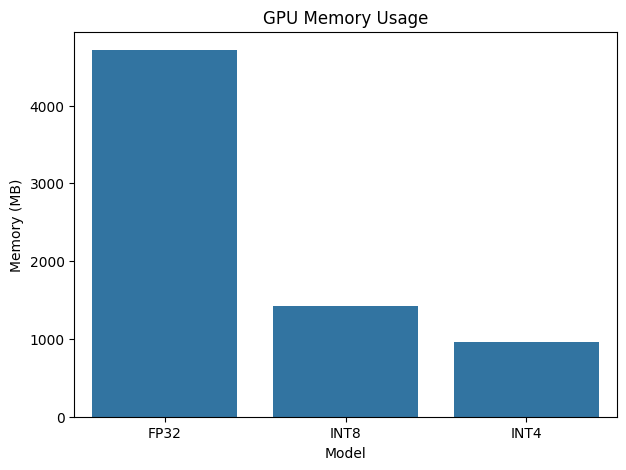

In [19]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="Memory_MB",
    data=results_df
)

plt.title("GPU Memory Usage")
plt.ylabel("Memory (MB)")
plt.show()

**Plot: Perplexity**

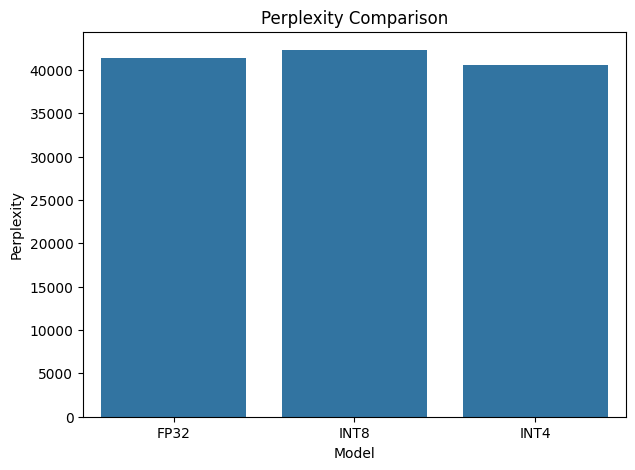

In [20]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="Perplexity",
    data=results_df
)

plt.title("Perplexity Comparison")
plt.show()

**Heatmap Comparison**

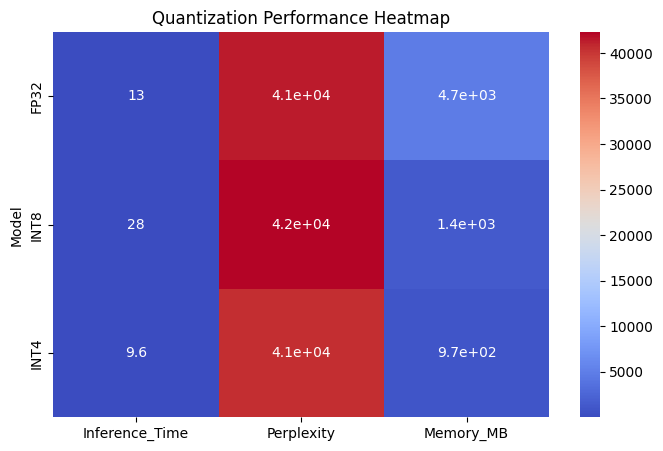

In [21]:
plt.figure(figsize=(8,5))

sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    cmap="coolwarm"
)

plt.title("Quantization Performance Heatmap")
plt.show()